In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv("anime.csv")

df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [ ]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [ ]:
df.isnull(  ).sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


# Exploratory Data Analysis (EDA)

EDA was performed to understand the structure
of the anime dataset.

The following steps were performed:
- Checked dataset information
- Verified missing values
- Generated summary statistics
- Explored dataset attributes

EDA helps identify patterns and inconsistencies
before building the recommendation system.

In [ ]:
df['genre'] = df['genre'].fillna('Unknown')

df['rating'] = df['rating'].fillna(
    df['rating'].mean()
)

df['episodes'] = df['episodes'].replace(
    'Unknown',
    np.nan
)

df['episodes'] = pd.to_numeric(
    df['episodes'],
    errors='coerce'
)

df['episodes'] = df['episodes'].fillna(
    df['episodes'].mean()
)

In [ ]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,0
type,25
episodes,0
rating,0
members,0


# Data Preprocessing

Missing values were handled using:
- Mean imputation for numerical features
- Replacement of missing genres with 'Unknown'

The dataset was cleaned to improve
recommendation quality.

In [ ]:
vectorizer = CountVectorizer(
    tokenizer=lambda x: x.split(", ")
)

genre_matrix = vectorizer.fit_transform(
    df['genre']
)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
scaler = MinMaxScaler()

numerical_features = scaler.fit_transform(
    df[['rating', 'episodes']]
)

In [ ]:
from scipy.sparse import hstack

feature_matrix = hstack([
    genre_matrix,
    numerical_features
])

# Feature Extraction

Genres were converted into numerical format
using CountVectorizer.

Numerical features such as ratings and episodes
were normalized using MinMaxScaler.

Feature extraction helps represent anime
in numerical form for similarity calculations.

In [ ]:
cosine_sim = cosine_similarity(
    feature_matrix
)

print(cosine_sim)

[[1.         0.29878478 0.13644327 ... 0.15085848 0.15492584 0.1737458 ]
 [0.29878478 1.         0.36143579 ... 0.11709589 0.12023337 0.13483898]
 [0.13644327 0.36143579 1.         ... 0.11695735 0.12009513 0.13468395]
 ...
 [0.15085848 0.11709589 0.11695735 ... 1.         0.99994463 0.99824866]
 [0.15492584 0.12023337 0.12009513 ... 0.99994463 1.         0.99881138]
 [0.1737458  0.13483898 0.13468395 ... 0.99824866 0.99881138 1.        ]]


# Cosine Similarity

Cosine similarity measures similarity between anime
based on their feature vectors.

Higher cosine similarity values indicate
more similar anime.

In [ ]:
def recommend_anime(title, cosine_sim=cosine_sim):

    idx = df[df['name'] == title].index[0]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:6]

    anime_indices = [
        i[0] for i in similarity_scores
    ]

    return df['name'].iloc[anime_indices]

In [ ]:
recommend_anime("Naruto")

,name
615,Naruto: Shippuuden
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...
486,Boruto: Naruto the Movie
1343,Naruto x UT
1472,Naruto: Shippuuden Movie 4 - The Lost Tower


# Recommendation System

A recommendation function was created
using cosine similarity.

The system recommends anime that are most similar
to the selected anime based on genres,
ratings, and episodes.

In [ ]:
def recommend_with_threshold(
    title,
    threshold=0.5
):

    idx = df[df['name'] == title].index[0]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    filtered_scores = [
        x for x in similarity_scores
        if x[1] > threshold
    ]

    filtered_scores = sorted(
        filtered_scores,
        key=lambda x: x[1],
        reverse=True
    )

    anime_indices = [
        i[0] for i in filtered_scores[1:6]
    ]

    return df['name'].iloc[anime_indices]

In [ ]:
recommend_with_threshold(
    "Naruto",
    threshold=0.6
)

,name
615,Naruto: Shippuuden
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...
486,Boruto: Naruto the Movie
1343,Naruto x UT
1472,Naruto: Shippuuden Movie 4 - The Lost Tower


# Threshold Analysis

Different threshold values were tested
to control recommendation quality.

Higher thresholds produce more accurate
but fewer recommendations.

Lower thresholds produce more recommendations
with lower similarity.

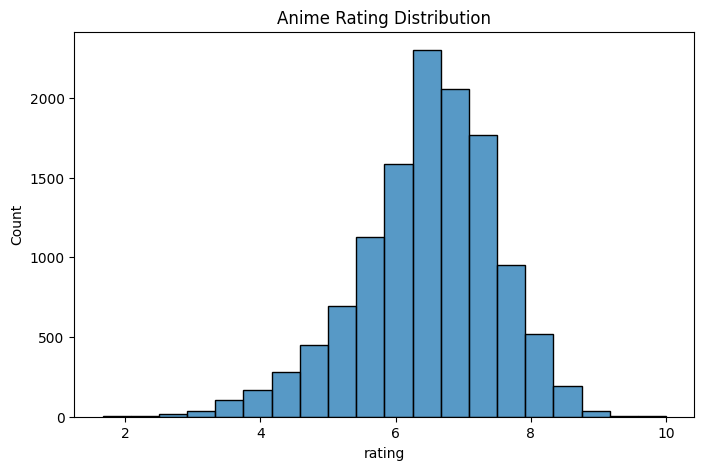

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['rating'],
    bins=20
)

plt.title("Anime Rating Distribution")

plt.show()

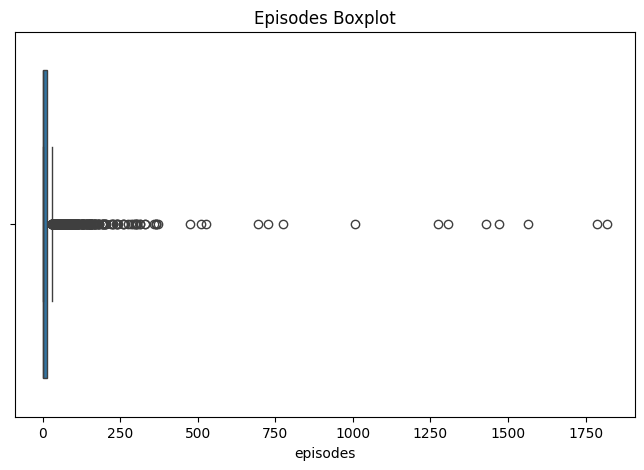

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['episodes']
)

plt.title("Episodes Boxplot")

plt.show()

# Data Visualization

Visualizations were created to analyze:
- Rating distributions
- Episode distributions
- Dataset variability

These plots help understand the dataset characteristics.

Conclusion

A recommendation system was successfully built
using cosine similarity.

Genres, ratings, and episode counts were used
to compute anime similarity.

The recommendation system suggests similar anime
based on feature similarity.

Cosine similarity effectively measures
relationships between anime.

# Interview Questions


### 1. Can you explain the difference between user-based and item-based collaborative filtering?

Answer: User-based and item-based collaborative filtering are both recommendation techniques, but they work in different ways.

In user-based collaborative filtering, the system looks for users who have similar preferences. If two users have liked or rated similar items in the past, the system assumes they have similar tastes. So, it recommends items that one user liked but the other hasn't seen yet.

For example, if you and I both like the same movies, and you've watched a movie that I haven't, the system may recommend that movie to me.

In item-based collaborative filtering, instead of comparing users, the system compares the items themselves. It identifies items that are frequently liked or purchased together. If a user likes one item, the system recommends other similar items.

For example, if many people who bought an iPhone also bought AirPods, then someone purchasing an iPhone may receive a recommendation for AirPods.

In practice, item-based collaborative filtering is more commonly used because item relationships don't change as frequently as user preferences. It's generally more stable and scales better for large applications.




### 2. What is collaborative filtering, and how does it work?

Answer: Collaborative filtering is a recommendation technique used to suggest products, movies, songs, or other items to users based on the preferences and behavior of other users. The main idea is that if people have liked similar things in the past, they are likely to have similar interests in the future.

It works by analyzing user interactions, such as ratings, purchases, clicks, or watch history. Based on this data, the system identifies patterns and makes recommendations. There are two main approaches:

User-based collaborative filtering, where the system finds users with similar preferences and recommends items that those users liked.

Item-based collaborative filtering, where the system finds items that are similar based on user behavior and recommends those similar items.

A common example is Netflix or Amazon. If users who watched the same movies as you also watched another movie that you haven't seen, the system recommends that movie to you. Similarly, on Amazon, if people who bought a laptop also bought a wireless mouse, it may recommend the mouse to you.

Overall, collaborative filtering provides personalized recommendations without needing to know the details of the items—it mainly relies on user behavior and historical data.